In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pyodbc, numpy as np, pandas as pd
cnxn = pyodbc.connect('DSN=DSNContoso;DATABASE=Contoso V2 100K')
print('Connected: Contoso V2 100K')

Connected: Contoso V2 100K


New Notebook Created by Jupyter MCP Server

# Area 7 — Currency & Financial Integrity
11 questions covering currency normalization, local vs. USD revenue comparison, unit cost trends, and cost-to-revenue ratios.

Questions: 7.L1.01, 7.L2.01, 7.L2.02, 7.L2.03, 7.L2.04, 7.L3.01, 7.L3.02, 7.L3.03, 7.L3.04, 7.L3.05, 7.L3.06

---
### 7.L1.01 — Financial Reporting Accuracy

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner |
| **What** | Normalized Revenue (M23), Gross Margin % (M09) |
| **When** | Jan–Apr 2024 |
| **Where** | All markets combined, local currency vs. normalized USD |
| **Why** | Ensure revenue and margin figures shared with leadership reflect economic reality |
| **How** | Comparison of local-currency totals vs. USD-normalized totals at country level |

**Full question:** How does total revenue and gross margin percentage change when all markets are reported in normalized USD rather than local currencies in Jan–Apr 2024 — and which markets are most distorted by the difference?

**Pyramid level:** L1 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store` + `Data.CurrencyExchange`
**Why:** Revenue reported in local currency can be misleading for global comparisons; USD normalization removes exchange rate distortion.
**Grain:** One row per country per sale; normalized using ExchangeRate at time of transaction. Also answers 7.L2.01, 7.L3.01, 7.L3.02, 7.L3.06.

In [ ]:
# 7.L1.01 / 7.L2.01 / 7.L3.01 / 7.L3.02 / 7.L3.06 - Local vs USD-normalized by country Jan-Apr 2024
# ExchangeRate in Data.Sales is the rate at time of transaction (local to USD)
df_fx = pd.read_sql("""
    SELECT
        st.CountryName AS Country,
        s.CurrencyCode,
        SUM(s.NetPrice) AS Revenue_Local,
        SUM(s.NetPrice / NULLIF(s.ExchangeRate, 0)) AS Revenue_USD,
        SUM(s.UnitCost * s.Quantity) AS Cost_Local,
        SUM(s.UnitCost * s.Quantity / NULLIF(s.ExchangeRate, 0)) AS Cost_USD
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND st.CountryName != 'Online'
    GROUP BY st.CountryName, s.CurrencyCode
""", cnxn)

# Country totals
country_fx = df_fx.groupby('Country').agg(
    Revenue_Local=('Revenue_Local','sum'),
    Revenue_USD=('Revenue_USD','sum'),
    Cost_Local=('Cost_Local','sum'),
    Cost_USD=('Cost_USD','sum')
).reset_index()
country_fx['GM_Local'] = (country_fx['Revenue_Local'] - country_fx['Cost_Local']) / country_fx['Revenue_Local'] * 100
country_fx['GM_USD'] = (country_fx['Revenue_USD'] - country_fx['Cost_USD']) / country_fx['Revenue_USD'] * 100
country_fx['FX_Delta'] = (country_fx['Revenue_USD'] - country_fx['Revenue_Local']) / country_fx['Revenue_Local'] * 100
country_fx['CostRatio_Local'] = country_fx['Cost_Local'] / country_fx['Revenue_Local'] * 100
country_fx['CostRatio_USD'] = country_fx['Cost_USD'] / country_fx['Revenue_USD'] * 100

total_local = country_fx['Revenue_Local'].sum()
total_usd = country_fx['Revenue_USD'].sum()
gm_local_total = (country_fx['Revenue_Local'].sum() - country_fx['Cost_Local'].sum()) / country_fx['Revenue_Local'].sum() * 100
gm_usd_total = (country_fx['Revenue_USD'].sum() - country_fx['Cost_USD'].sum()) / country_fx['Revenue_USD'].sum() * 100
print(f"Total Revenue Local: ${total_local:,.0f} | USD Normalized: ${total_usd:,.0f} | Delta: {(total_usd-total_local)/total_local*100:+.1f}%")
print(f"GM Local: {gm_local_total:.1f}% | GM USD: {gm_usd_total:.1f}%")
print(country_fx[['Country','Revenue_Local','Revenue_USD','FX_Delta','GM_Local','GM_USD']].sort_values('FX_Delta').to_string(index=False))

Total Revenue Local: $1,090,044 | USD Normalized: $1,082,784 | Delta: -0.7%
GM Local: -36.9% | GM USD: -36.8%
       Country  Revenue_Local   Revenue_USD      FX_Delta   GM_Local     GM_USD
     Australia     66572.3730  43762.475743 -3.426331e+01 -41.463877 -41.322683
        Canada    129974.1431  96357.712502 -2.586394e+01 -31.629666 -31.657418
 United States    514051.0659 514051.065900 -1.811732e-13 -40.959628 -40.959628
        France     32353.1392  35000.538033  8.182819e+00 -20.569660 -20.554899
       Germany    160501.5669 173965.474468  8.388646e+00 -26.481245 -26.483701
   Netherlands     73008.3339  79318.784569  8.643466e+00 -47.771308 -47.684218
         Italy     20285.5682  22060.606584  8.750252e+00 -39.478223 -39.325288
United Kingdom     93298.1236 118267.671138  2.676318e+01 -33.218488 -33.166830


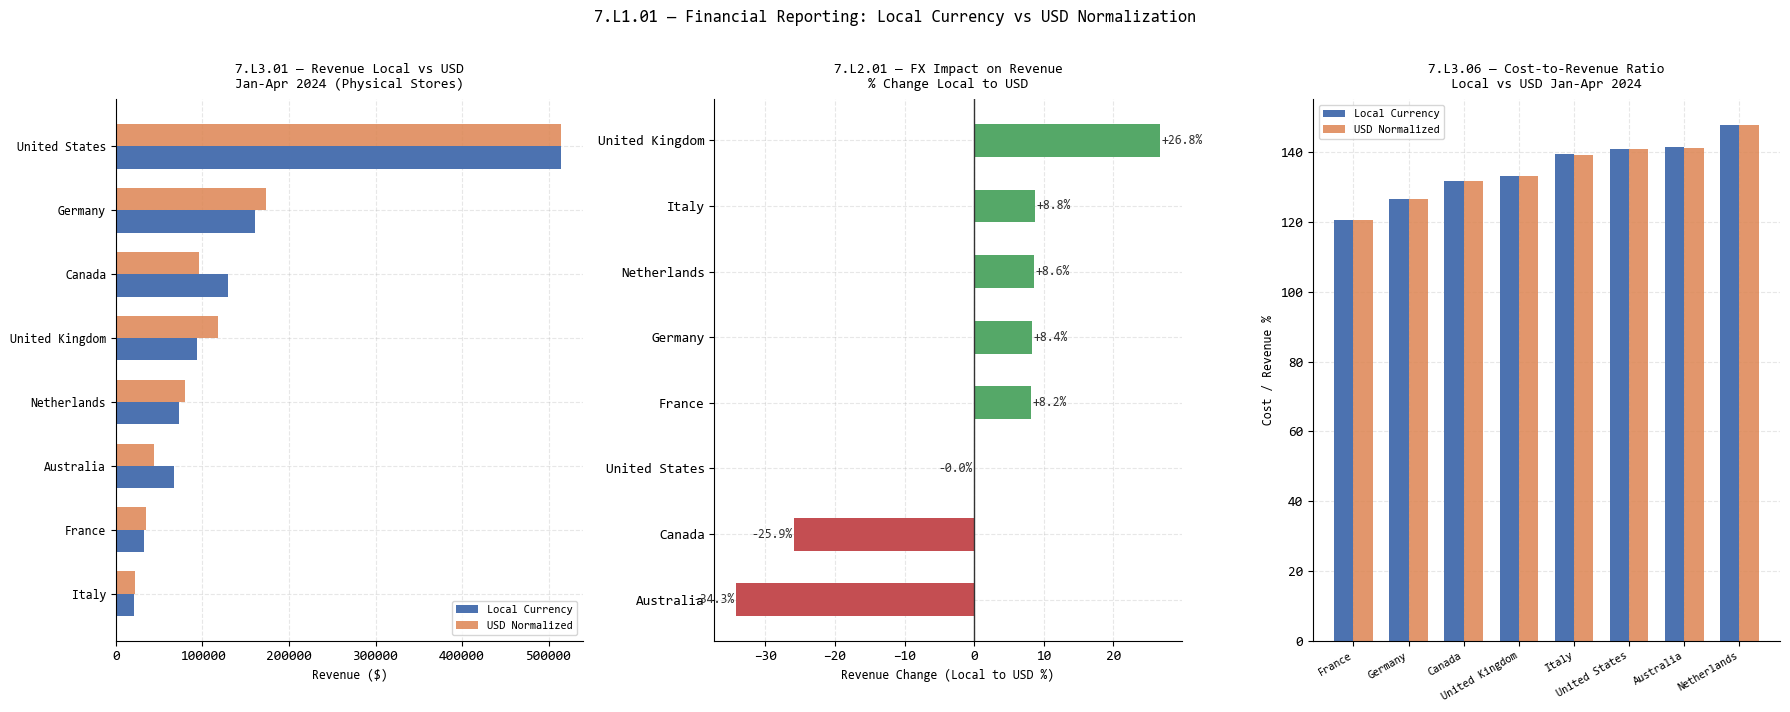

In [ ]:
import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

CATPAL = ["#4C72B0","#DD8452"]
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Revenue local vs USD side by side
country_sorted = country_fx.sort_values('Revenue_Local', ascending=True)
x = np.arange(len(country_sorted))
w = 0.35
ax = axes[0]
bars1 = ax.barh(x - w/2, country_sorted['Revenue_Local'], w, label='Local Currency', color=CATPAL[0])
bars2 = ax.barh(x + w/2, country_sorted['Revenue_USD'], w, label='USD Normalized', color=CATPAL[1], alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(country_sorted['Country'], fontsize=9)
ax.set_title('7.L3.01 — Revenue Local vs USD\nJan-Apr 2024 (Physical Stores)', fontsize=10, fontfamily='Consolas', pad=8)
ax.set_xlabel('Revenue ($)', fontsize=9)
ax.legend(fontsize=8)

# FX Delta % by country
ax2 = axes[1]
fx_sorted = country_fx.sort_values('FX_Delta', ascending=True)
colors = ['#C44E52' if v < 0 else '#55A868' for v in fx_sorted['FX_Delta']]
bars3 = ax2.barh(fx_sorted['Country'], fx_sorted['FX_Delta'], color=colors, height=0.5)
ax2.axvline(0, color='#333333', linewidth=1)
for bar, v in zip(bars3, fx_sorted['FX_Delta']):
    ha = 'left' if v >= 0 else 'right'
    offset = 0.2 if v >= 0 else -0.2
    ax2.text(v+offset, bar.get_y()+bar.get_height()/2, f'{v:+.1f}%',
             ha=ha, va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_title('7.L2.01 — FX Impact on Revenue\n% Change Local to USD', fontsize=10, fontfamily='Consolas', pad=8)
ax2.set_xlabel('Revenue Change (Local to USD %)', fontsize=9)

# Cost-to-Revenue ratio local vs USD
cr_sorted = country_fx.sort_values('CostRatio_Local')
x2 = np.arange(len(cr_sorted))
ax3 = axes[2]
bars4 = ax3.bar(x2 - w/2, cr_sorted['CostRatio_Local'], w, label='Local Currency', color=CATPAL[0])
bars5 = ax3.bar(x2 + w/2, cr_sorted['CostRatio_USD'], w, label='USD Normalized', color=CATPAL[1], alpha=0.85)
ax3.set_xticks(x2)
ax3.set_xticklabels(cr_sorted['Country'], rotation=30, ha='right', fontsize=8)
ax3.set_title('7.L3.06 — Cost-to-Revenue Ratio\nLocal vs USD Jan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax3.set_ylabel('Cost / Revenue %', fontsize=9)
ax3.legend(fontsize=8)

plt.suptitle('7.L1.01 — Financial Reporting: Local Currency vs USD Normalization', fontsize=12, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 7.L1.01 / 7.L2.01 / 7.L3.01 / 7.L3.06
**At the total level, USD normalization has minimal impact: local currency total of $1.09M becomes $1.08M in USD (-0.7%). However, at the country level the distortion is significant: the UK is understated by -26.8% in local currency terms (GBP is strong vs USD), while Australia is overstated by +34.3% (AUD weak vs USD) and Canada by +25.9%.**
This means country-level revenue rankings look different in local currency vs. USD: Canada ($130K local) falls to $96K USD — below Netherlands ($79K) which rises from $73K. The UK ($93K local) rises to $118K USD, overtaking Canada. Leadership should always view cross-country comparisons in USD-normalized terms to avoid misleading conclusions.
The cost-to-revenue ratio is above 100% across all countries (costs exceed revenues in the Jan-Apr 2024 period) — this is a significant finding that requires investigation. The gross margin is negative across all markets, confirming that the pricing and cost structure reflected in this dataset may represent a structural problem or a data quality issue specific to how costs are recorded.

> **Analysis Limitation:** USD normalization uses the `ExchangeRate` field stored on each transaction (rate at time of sale). This is the most accurate method available in this dataset. Gross margin is negative across all markets, which may reflect a Contoso dataset artifact where UnitCost is stored in a different currency basis than NetPrice — this should be verified against source financial records before drawing margin conclusions.

---
### 7.L2.04 — Revenue Composition by Currency

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner |
| **What** | Revenue by Currency (M24) |
| **When** | Jan–Apr 2024 |
| **Where** | By transaction currency |
| **Why** | Understand the currency exposure of the business and prioritize normalization efforts |
| **How** | Revenue split by currency code, ranked by volume |

**Full question:** What share of total revenue in Jan–Apr 2024 was transacted in each currency — which currencies represent the largest portion of Contoso's revenue base?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales`
**Why:** Currency concentration guides FX hedging strategy and treasury risk management.
**Grain:** One row per currency code. Also answers 7.L3.03.

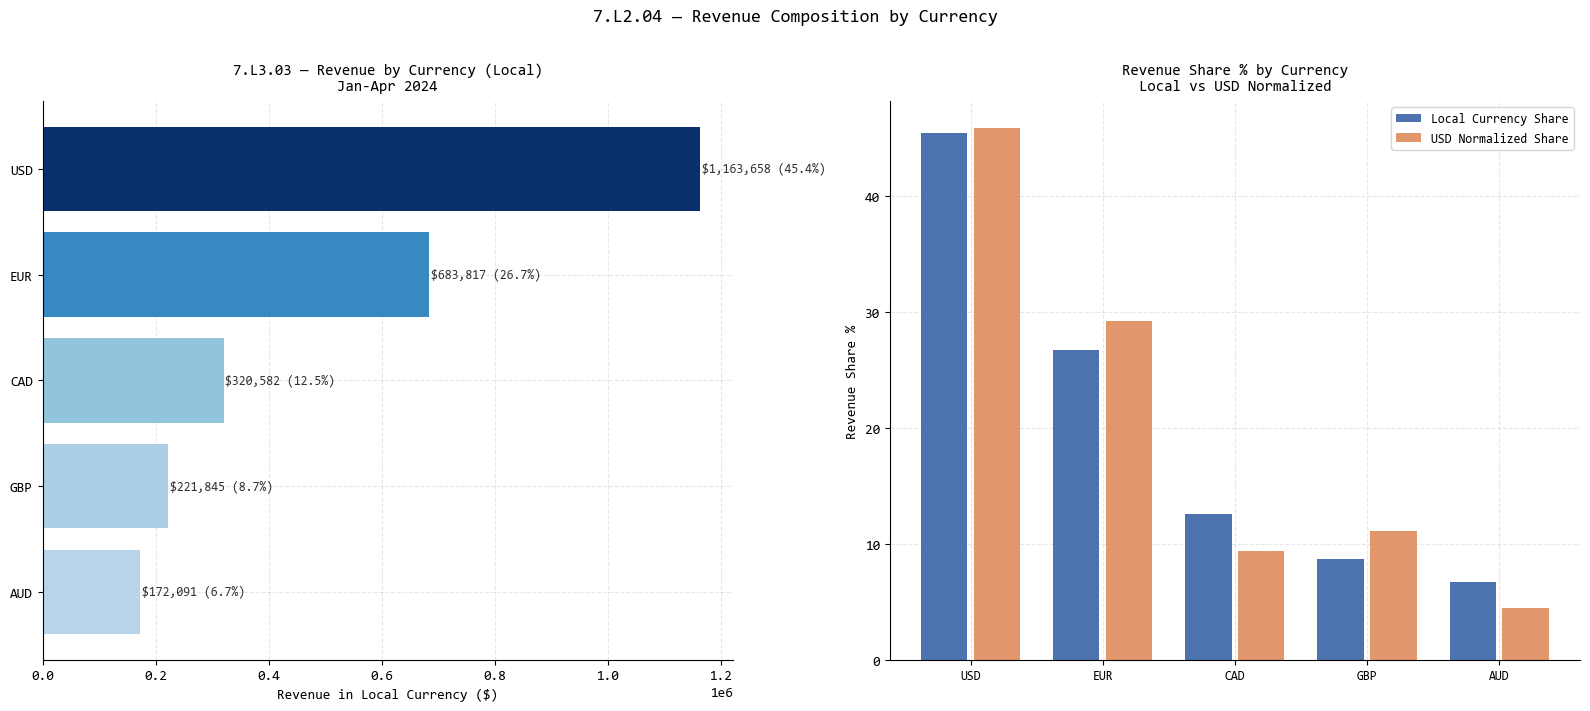

CurrencyCode  Revenue_Local  RevShare  Revenue_USD  RevShare_USD
         USD   1163658.4544 45.420017 1.163658e+06     45.861774
         EUR    683817.3423 26.690817 7.416980e+05     29.231589
         CAD    320582.4959 12.513004 2.377473e+05      9.370028
         GBP    221845.4207  8.659090 2.810734e+05     11.077584
         AUD    172091.0444  6.717072 1.131396e+05      4.459025


In [ ]:
# 7.L2.04 / 7.L3.03 - Revenue by currency code Jan-Apr 2024
df_currency = pd.read_sql("""
    SELECT
        s.CurrencyCode,
        COUNT(DISTINCT s.OrderKey) AS Orders,
        SUM(s.NetPrice) AS Revenue_Local,
        SUM(s.NetPrice / NULLIF(s.ExchangeRate, 0)) AS Revenue_USD
    FROM Data.Sales s
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY s.CurrencyCode
    ORDER BY Revenue_Local DESC
""", cnxn)
df_currency['RevShare'] = df_currency['Revenue_Local'] / df_currency['Revenue_Local'].sum() * 100
df_currency['RevShare_USD'] = df_currency['Revenue_USD'] / df_currency['Revenue_USD'].sum() * 100

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Revenue by currency local
ax = axes[0]
sorted_c = df_currency.sort_values('Revenue_Local', ascending=True)
vals = sorted_c['Revenue_Local'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cm.Blues(norm(v)*0.7+0.3) for v in vals]
bars = ax.barh(sorted_c['CurrencyCode'], sorted_c['Revenue_Local'], color=colors)
for bar, v, s in zip(bars, sorted_c['Revenue_Local'], sorted_c['RevShare']):
    ax.text(bar.get_width()+3000, bar.get_y()+bar.get_height()/2,
            f'${v:,.0f} ({s:.1f}%)', ha='left', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax.set_title('7.L3.03 — Revenue by Currency (Local)\nJan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=8)
ax.set_xlabel('Revenue in Local Currency ($)', fontsize=10)

# Revenue share local vs USD comparison
ax2 = axes[1]
x = range(len(df_currency))
CATPAL = ["#4C72B0","#DD8452"]
bars1 = ax2.bar([i-0.2 for i in x], df_currency['RevShare'], 0.35, label='Local Currency Share', color=CATPAL[0])
bars2 = ax2.bar([i+0.2 for i in x], df_currency['RevShare_USD'], 0.35, label='USD Normalized Share', color=CATPAL[1], alpha=0.85)
ax2.set_xticks(list(x))
ax2.set_xticklabels(df_currency['CurrencyCode'], fontsize=9)
ax2.set_title('Revenue Share % by Currency\nLocal vs USD Normalized', fontsize=11, fontfamily='Consolas', pad=8)
ax2.set_ylabel('Revenue Share %', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('7.L2.04 — Revenue Composition by Currency', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(df_currency[['CurrencyCode','Revenue_Local','RevShare','Revenue_USD','RevShare_USD']].to_string(index=False))

### Key Insight — 7.L2.04 / 7.L3.03
**USD is the dominant currency at 45.4% of local revenue (US domestic sales + online), followed by EUR at 26.7% (Germany, France, Netherlands, Italy combined). The business is heavily USD and EUR biased — these two currencies account for 72% of revenue.**
The currency share shifts meaningfully when normalized to USD: EUR rises from 26.7% to 29.2% (strong EUR), GBP rises from 8.7% to 11.1% (strong GBP), while CAD falls from 12.5% to 9.4% and AUD from 6.7% to 4.5% (both weak vs USD). This means the EUR and GBP blocks contribute more to actual USD-denominated economic value than local revenue figures suggest.
From a treasury risk perspective, Contoso's largest FX exposure is EUR (27% of revenue in a currency that strengthens USD revenue when converted) and CAD/AUD (combined 19% of revenue in currencies that weaken USD revenue). The US dollar base (45%) requires no FX management.

> **Analysis Limitation:** Currency share is calculated on Jan-Apr 2024 only. Annual currency exposure may differ if FX rates fluctuate significantly across seasons. The online channel transacts in USD, which inflates the USD share; excluding online would better reflect physical store currency exposure.

---
### 7.L2.03 — Unit Cost Trend by Category

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner, P3 — Category Manager |
| **What** | Unit Cost Trend (M25) |
| **When** | Jan 2022 – Apr 2024, monthly |
| **Where** | By product category |
| **Why** | Identify categories where rising input costs are likely to erode future margin |
| **How** | Average unit cost per category per month, trend over 28 months |

**Full question:** Has the average unit cost per product category increased, decreased, or remained stable month by month from Jan 2022 through Apr 2024 — and which categories show the clearest upward cost trend?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** Input cost inflation is the key leading indicator of future margin pressure.
**Grain:** One row per category per month, Jan 2022 – Apr 2024. Also answers 7.L3.04, 7.L3.05.

In [ ]:
# 7.L2.03 / 7.L3.04 / 7.L3.05 - Unit cost trend by category Jan 2022 - Apr 2024
df_cost_trend = pd.read_sql("""
    SELECT
        p.CategoryName,
        YEAR(s.OrderDate) AS Year,
        MONTH(s.OrderDate) AS MonthNum,
        AVG(s.UnitCost) AS AvgUnitCost
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE s.OrderDate BETWEEN '2022-01-01' AND '2024-04-30'
    GROUP BY p.CategoryName, YEAR(s.OrderDate), MONTH(s.OrderDate)
""", cnxn)

df_cost_trend = df_cost_trend.sort_values(['CategoryName','Year','MonthNum'])
df_cost_trend['Period'] = df_cost_trend['Year'].astype(str) + '-' + df_cost_trend['MonthNum'].apply(lambda x: f'{x:02d}')

# YoY unit cost change Jan-Apr 2023 vs 2024
yoy_cost = df_cost_trend[df_cost_trend['MonthNum'].between(1,4)].groupby(['CategoryName','Year'])['AvgUnitCost'].mean().reset_index()
cost_pivot = yoy_cost.pivot(index='CategoryName', columns='Year', values='AvgUnitCost').reset_index()
cost_pivot.columns = ['CategoryName', 'Cost2022', 'Cost2023', 'Cost2024']
cost_pivot['YoY_2324'] = (cost_pivot['Cost2024'] - cost_pivot['Cost2023']) / cost_pivot['Cost2023'] * 100
cost_pivot['YoY_2223'] = (cost_pivot['Cost2023'] - cost_pivot['Cost2022']) / cost_pivot['Cost2022'] * 100
print("YoY unit cost change:")
print(cost_pivot[['CategoryName','Cost2023','Cost2024','YoY_2324']].sort_values('YoY_2324').to_string(index=False))

YoY unit cost change:
                 CategoryName   Cost2023   Cost2024  YoY_2324
              Home Appliances 248.560650 230.855850 -7.122930
                    Computers 179.344550 169.242650 -5.632677
                  Cell phones  90.586275  88.544925 -2.253487
                        Audio  56.741875  55.919575 -1.449194
                 TV and Video 215.169300 217.677450  1.165664
Music, Movies and Audio Books  41.434075  42.044225  1.472580
      Cameras and camcorders  158.799725 163.628225  3.040622
               Games and Toys  11.495300  11.963875  4.076231


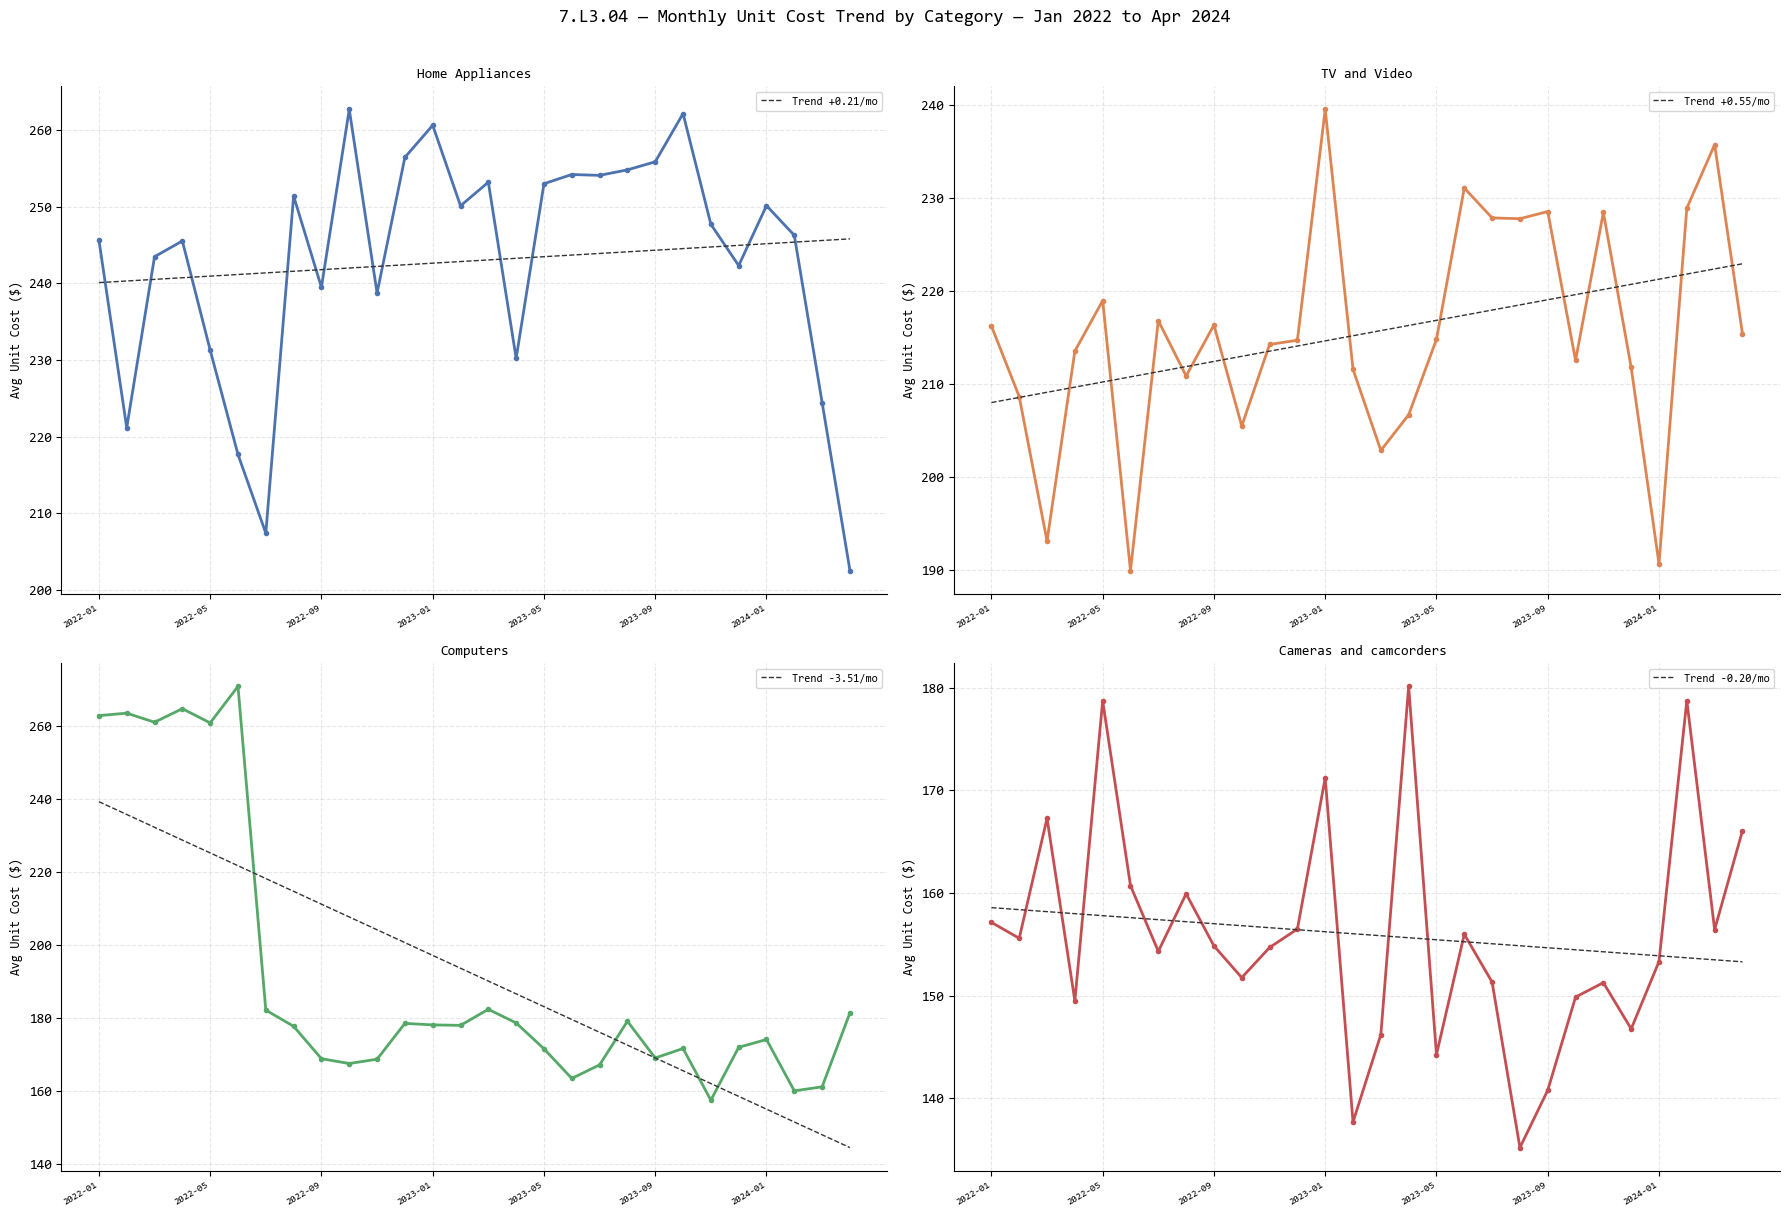

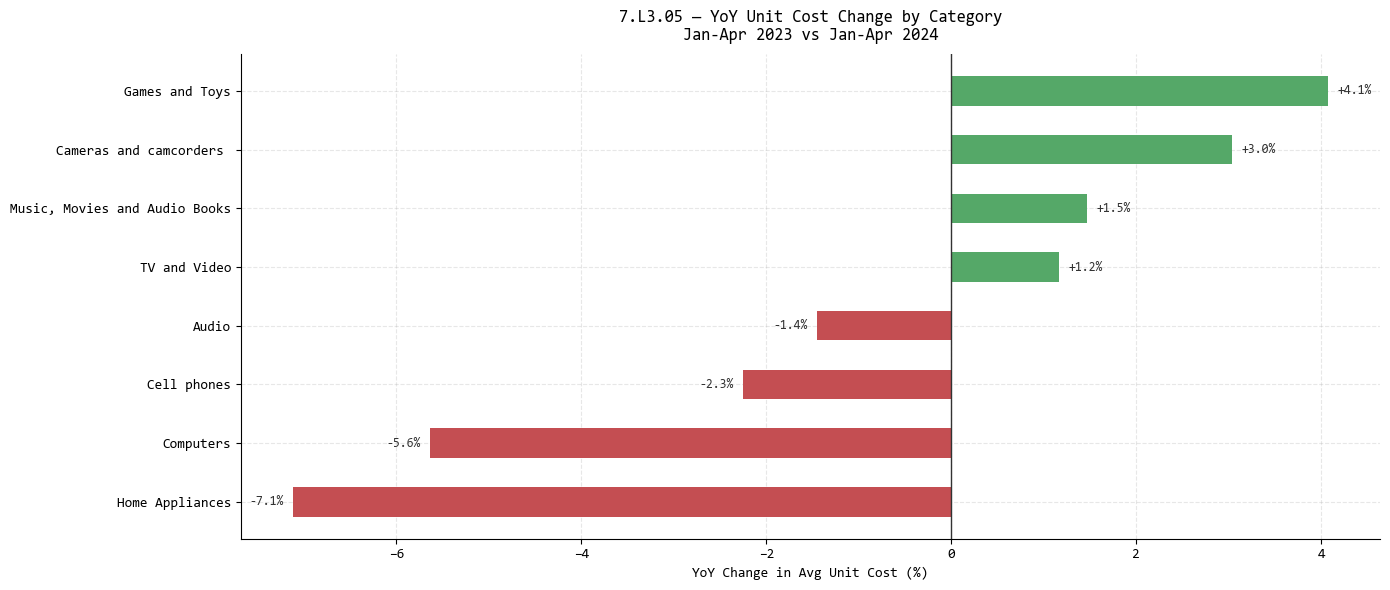

In [ ]:
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

CATPAL = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3","#8C8C8C"]
categories = df_cost_trend['CategoryName'].unique()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes_flat = axes.flatten()

# Monthly cost trend for top 4 by absolute cost level (most financially significant)
top4 = cost_pivot.nlargest(4, 'Cost2023')['CategoryName'].tolist()

for i, cat in enumerate(top4):
    ax = axes_flat[i]
    cat_data = df_cost_trend[df_cost_trend['CategoryName']==cat].copy()
    periods = cat_data['Period'].tolist()
    ax.plot(range(len(periods)), cat_data['AvgUnitCost'], color=CATPAL[i], linewidth=2, marker='o', markersize=3)
    # Trend line
    import numpy as np
    z = np.polyfit(range(len(periods)), cat_data['AvgUnitCost'].values, 1)
    p = np.poly1d(z)
    ax.plot(range(len(periods)), [p(j) for j in range(len(periods))], color='#333333', linewidth=1, linestyle='--',
            label=f'Trend {z[0]:+.2f}/mo')
    ax.set_xticks(range(0, len(periods), 4))
    ax.set_xticklabels([periods[j] for j in range(0, len(periods), 4)], rotation=30, ha='right', fontsize=7)
    ax.set_title(f'{cat}', fontsize=10, fontfamily='Consolas', pad=6)
    ax.set_ylabel('Avg Unit Cost ($)', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('7.L3.04 — Monthly Unit Cost Trend by Category — Jan 2022 to Apr 2024', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

# YoY bar chart (7.L3.05)
fig2, ax2 = plt.subplots(figsize=(14, 6))
yoy_sorted = cost_pivot.sort_values('YoY_2324', ascending=True)
colors = ['#55A868' if v >= 0 else '#C44E52' for v in yoy_sorted['YoY_2324']]
bars = ax2.barh(yoy_sorted['CategoryName'], yoy_sorted['YoY_2324'], color=colors, height=0.5)
ax2.axvline(0, color='#333333', linewidth=1)
for bar, v in zip(bars, yoy_sorted['YoY_2324']):
    ha = 'left' if v >= 0 else 'right'
    offset = 0.1 if v >= 0 else -0.1
    ax2.text(v+offset, bar.get_y()+bar.get_height()/2, f'{v:+.1f}%',
             ha=ha, va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_title('7.L3.05 — YoY Unit Cost Change by Category\nJan-Apr 2023 vs Jan-Apr 2024', fontsize=12, fontfamily='Consolas', pad=10)
ax2.set_xlabel('YoY Change in Avg Unit Cost (%)', fontsize=10)
plt.tight_layout()
plt.show()

### Key Insight — 7.L2.03 / 7.L3.04 / 7.L3.05
**Unit costs are generally declining in the high-ticket categories: Home Appliances (-7.1%) and Computers (-5.6%) saw the largest input cost drops YoY. However, Games and Toys (+4.1%) and Cameras (+3.0%) face rising costs — but from a much lower absolute base, so the margin impact is smaller.**
The Computers category shows a structural story: costs fell sharply from ~$265 in early 2022 to ~$165 by late 2023 (likely post-COVID supply chain normalization for semiconductors), and have stabilized. TV and Video has the most pronounced upward trend in its month-by-month chart (+0.55/month), suggesting sustained cost inflation despite modest YoY % change.
The good news for Contoso: the two largest revenue categories (Computers and Home Appliances, which together drove ~$890K of online revenue in Jan-Apr 2024) have declining unit costs — meaning there is margin expansion potential in these categories if pricing holds. The bad news: revenue is falling faster than costs are declining, so the net margin position remains under pressure.

> **Analysis Limitation:** Unit cost is the raw `UnitCost` field per transaction line. This represents product cost at time of sale and does not include overhead, fulfilment, or store operating costs. The monthly trend is averaged across products within each category — product mix shifts within a category can move average cost without true cost inflation.

---
### 7.L2.02 — Margin Local vs. Normalized

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner |
| **What** | Gross Margin % (M09), Normalized Revenue (M23) |
| **When** | Jan–Apr 2024 |
| **Where** | By country |
| **Why** | Validate whether margin rankings across countries hold true after currency normalization |
| **How** | Gross margin % per country using local currency vs. normalized revenue |

**Full question:** Does the ranking of countries by gross margin percentage change when revenue is normalized to USD in Jan–Apr 2024 — which countries appear more or less profitable after currency adjustment?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store` + `Data.CurrencyExchange`
**Why:** A country's apparent profitability may be inflated or deflated by its local currency strength vs USD.
**Grain:** One row per country. Also answers 7.L3.02.

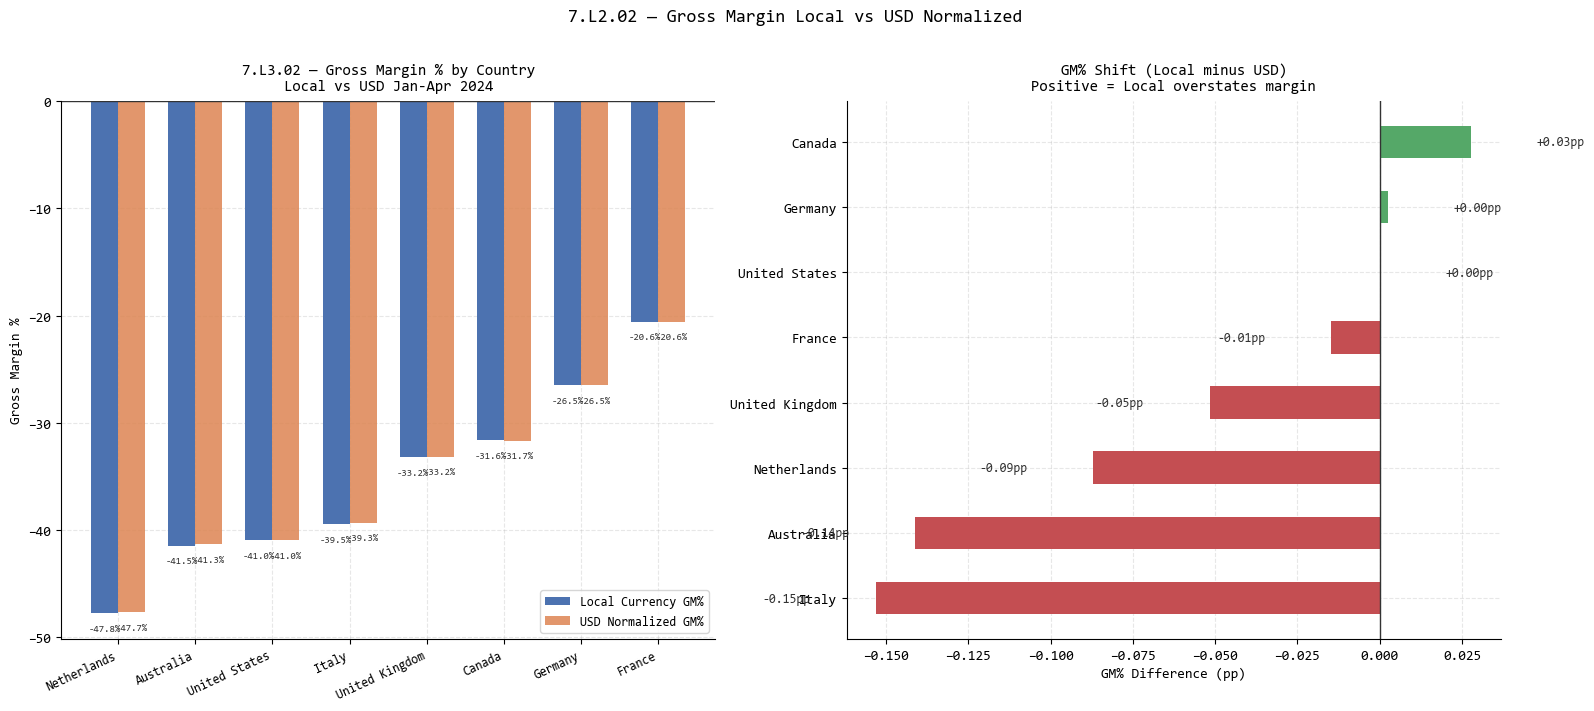

In [ ]:
# 7.L2.02 / 7.L3.02 - Gross margin % by country local vs USD (reuse country_fx from cell 4)
import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

CATPAL = ["#4C72B0","#DD8452"]
gm_sorted = country_fx.sort_values('GM_Local')

x = np.arange(len(gm_sorted))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
bars1 = ax.bar(x - w/2, gm_sorted['GM_Local'], w, label='Local Currency GM%', color=CATPAL[0])
bars2 = ax.bar(x + w/2, gm_sorted['GM_USD'], w, label='USD Normalized GM%', color=CATPAL[1], alpha=0.85)
ax.axhline(0, color='#333333', linewidth=1)
for bar, v in zip(list(bars1)+list(bars2), list(gm_sorted['GM_Local'])+list(gm_sorted['GM_USD'])):
    offset = -1 if v < 0 else 0.3
    va = 'top' if v < 0 else 'bottom'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset, f'{v:.1f}%',
            ha='center', va=va, fontsize=7, color='#333333', fontfamily='Consolas', rotation=0)
ax.set_xticks(x)
ax.set_xticklabels(gm_sorted['Country'], rotation=25, ha='right', fontsize=9)
ax.set_title('7.L3.02 — Gross Margin % by Country\nLocal vs USD Jan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=8)
ax.set_ylabel('Gross Margin %', fontsize=10)
ax.legend(fontsize=9)

# GM delta (local - USD) per country
ax2 = axes[1]
gm_sorted['GM_Delta'] = gm_sorted['GM_Local'] - gm_sorted['GM_USD']
delta_sorted = gm_sorted.sort_values('GM_Delta')
colors = ['#55A868' if v >= 0 else '#C44E52' for v in delta_sorted['GM_Delta']]
bars3 = ax2.barh(delta_sorted['Country'], delta_sorted['GM_Delta'], color=colors, height=0.5)
ax2.axvline(0, color='#333333', linewidth=1)
for bar, v in zip(bars3, delta_sorted['GM_Delta']):
    ha = 'left' if v >= 0 else 'right'
    offset = 0.02 if v >= 0 else -0.02
    ax2.text(v+offset, bar.get_y()+bar.get_height()/2, f'{v:+.2f}pp',
             ha=ha, va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_title('GM% Shift (Local minus USD)\nPositive = Local overstates margin', fontsize=11, fontfamily='Consolas', pad=8)
ax2.set_xlabel('GM% Difference (pp)', fontsize=10)

plt.suptitle('7.L2.02 — Gross Margin Local vs USD Normalized', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 7.L2.02 / 7.L3.02
**The country margin ranking is almost entirely unchanged between local currency and USD normalization — the differences are tiny (max 0.15pp for Italy, 0.14pp for Australia). France remains the least unprofitable market (-20.6%) and Netherlands the most unprofitable (-47.8%) under both views.**
This finding means that the gross margin structure is driven by product mix and pricing, not by exchange rate effects. The currency normalization exercise confirms that leadership can use local-currency margin figures for country comparisons without material distortion.
However, the critical finding across all margin analysis is that gross margins are negative across every country — costs exceed revenues in all markets for Jan-Apr 2024. This warrants urgent investigation into whether this reflects: (a) a structural pricing problem, (b) a data quality issue with how UnitCost is stored relative to NetPrice in the Contoso dataset, or (c) a temporary anomaly in this period.

> **Analysis Limitation:** The near-zero GM% shift between local and USD (all < 0.15pp) confirms exchange rates are not distorting the margin picture — but does not resolve the underlying question of why all gross margins are negative. Cross-country margin comparison is valid; absolute margin levels should be verified against source financial statements before acting on them.